# Analisis de dagtos II
### Pablo Salvagni

### Consigna
#### Actividad 1. Interpretabilidad de modelos
Descargar el dataset de salarios en data science disponible en Kaggle:
`https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023` y luego aplicar los
siguientes pasos:
#### Entrenamiento
Entrenar un modelo basado en árboles (por ejemplo, Random Forest) con hiperparámetros
por defecto, utilizando todas las variables disponibles. Evaluar brevemente su desempeño
con las métricas adecuadas.
#### Diagnóstico Global (PFI)
Analizar la importancia de las variables mediante PFI. Identificar las variables más
relevantes y señalar cualquier resultado llamativo o que requiera investigación.
#### Diagnóstico Local (SHAP)
Seleccionar dos observaciones con predicciones diferentes (por ejemplo, una predicción
alta y otra baja, o un caso con error pequeño y otro con error grande).

Para cada una, generar una explicación con SHAP y analizar:

- ¿Qué variables contribuyeron más? 
- ¿En qué dirección? 
- ¿La explicación es coherente con el análisis global?

#### Auditoría
A partir de los resultados obtenidos, identificar y justificar los hallazgos más relevantes
sobre el comportamiento del modelo.
Para cada hallazgo, discutir brevemente:
- ¿Qué evidencia proporcionan las técnicas de interpretabilidad?
- ¿El comportamiento es razonable para el problema?
- ¿Qué posible causa podría explicar ese comportamiento?
- ¿Qué acción tomarían para investigarlo o corregirlo?
Prestar especial atención a importancias inusualmente altas, variables redundantes o
información duplicada y posibles casos de data leakage.

Si detectan leakage, eliminar la variable problemática, reentrenar el modelo y comparar
brevemente con el modelo original: performance, importancia de las variables y
razonabilidad del comportamiento. No es necesario repetir todo el análisis detallado de
interpretabilidad.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Preparación y entrenamiento ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Interpretabilidad -------------------------------------
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

from alibi.explainers import ALE

#### 1. Importación de dataset      

In [ ]:
# Cargar el dataset desde archivo local
df = pd.read_csv('dataset/data-science-salaries-2023.csv')

# Mostrar las primeras filas para confirmar la carga
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


#### 2. Realizar un mini EDA 


In [ ]:
# Verificamos la estructura y si hay nulos
print(df.info())

# Resumen estadistico de variables numricas y categoricas
display(df.describe())
display(df.describe(include='object'))

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB
None


,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


/var/folders/d9/jdkvkdkj05vcnpwfbz5dxz7m0000gn/T/ipykernel_10490/3369691187.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


#### 3. Entrenar modelo con Random Forest

In [ ]:
# importo librerias para entrenar modelo
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score,  root_mean_squared_error

# importo libreria para guardar modelo
import joblib
from pathlib import Path

# 1. Defino variables predictoras y target
# Inicialmente uso TODAS las variables
X = df.drop(columns='salary_in_usd')
y = df['salary_in_usd']

# 2. Divido el dataset en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Identifico columnas categoricas para aplicar One-Hot Encoding
categorical_col = X.select_dtypes(include=['object']).columns.tolist()
# print(categorical_features)


# 4. creo el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_col),
    ],
    remainder='passthrough'
)

# 5. creo el pipeline para correr random forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])


# 6. entreno el modelo
rf_pipeline.fit(X_train, y_train)

# 7. evaluo el modelo
y_pred = rf_pipeline.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# 8. guardo el modelo por si surge utilizarlo en otra notebook
Path('modelos').mkdir(exist_ok=True)
joblib.dump(rf_pipeline, 'modelos/rf_salarios.joblib')

rf_pipeline = joblib.load('modelos/rf_salarios.joblib')
y_pred = rf_pipeline.predict(X_test)



/var/folders/d9/jdkvkdkj05vcnpwfbz5dxz7m0000gn/T/ipykernel_10490/2067110631.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = X.select_dtypes(include=['object']).columns.tolist()


MAE: 1248.34
RMSE: 8148.56
R2 Score: 0.9832


#### 4. Diagnostico Global (PFI)

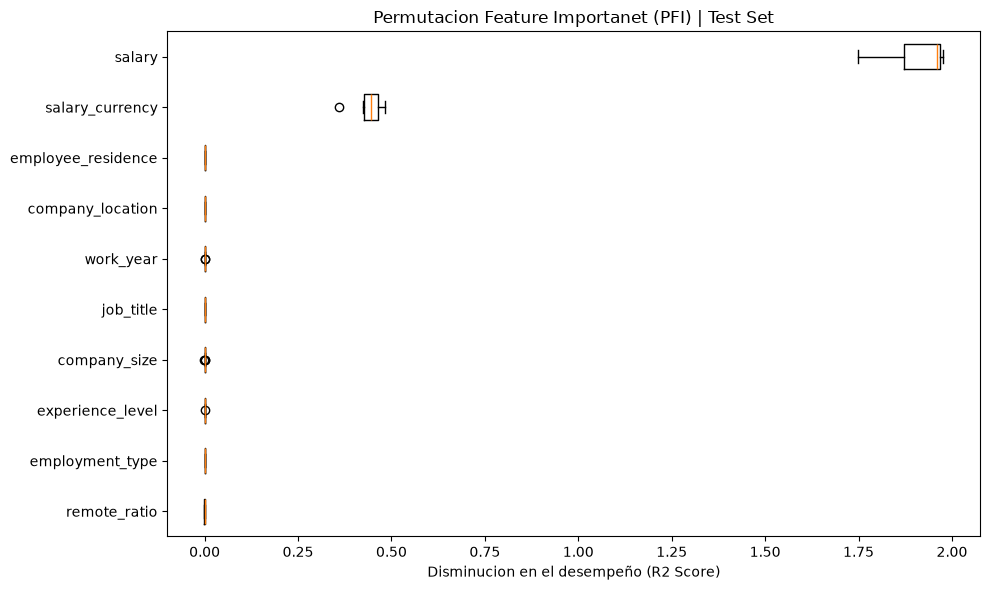

Importancia media de las variables (de mayor a menor):
salary: 1.9129
salary_currency: 0.4418
employee_residence: 0.0010
company_location: 0.0009
work_year: 0.0004
job_title: 0.0004
company_size: 0.0003
experience_level: 0.0001
employment_type: 0.0001
remote_ratio: -0.0001


In [ ]:
# importo libreria para calcular PFI
from sklearn.inspection import permutation_importance

# calculamos PFI para el modelo
pfi_result = permutation_importance(
    rf_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# obtenemos las importancias de las variables
sorted_idx = pfi_result.importances_mean.argsort()

# creo graficos de caja (boxplot) para ver importancias de variables
fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(
    pfi_result.importances[sorted_idx].T,
    orientation='horizontal',
    tick_labels=X_test.columns[sorted_idx]
)
ax.set_title('Permutacion Feature Importanet (PFI) | Test Set')
ax.set_xlabel('Disminucion en el desempeño (R2 Score)')
fig.tight_layout()
plt.show()

# imprimo los valores medios para ver mas detalle
print("Importancia media de las variables (de mayor a menor):")
for index in sorted_idx[::-1]:
    print(f"{X_test.columns[index]}: {pfi_result.importances_mean[index]:.4f}")




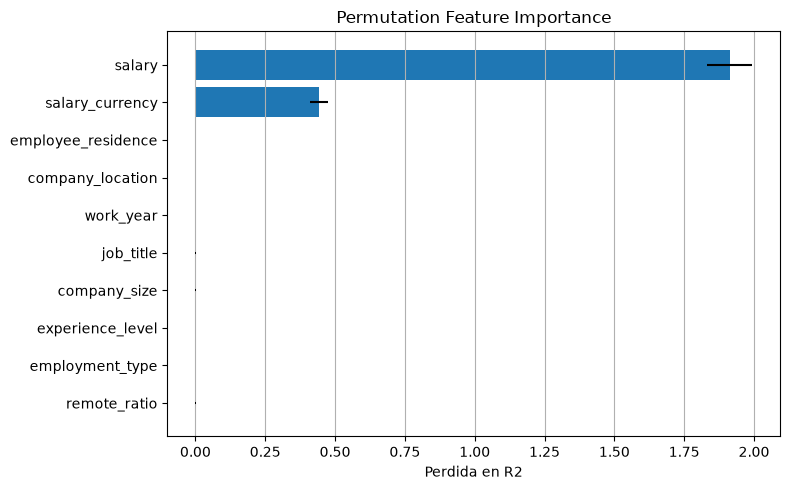

In [ ]:
# otra visualizacion para analizar mejor las estadisticas

pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": pfi_result.importances_mean,
    "std": pfi_result.importances_std
}).sort_values("importance", ascending=False)
plt.figure(figsize=(8, 5))
plt.barh(pfi["feature"], pfi["importance"], xerr=pfi["std"])
plt.xlabel("Perdida en R2")
plt.title("Permutation Feature Importance")
plt.grid(axis="x")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

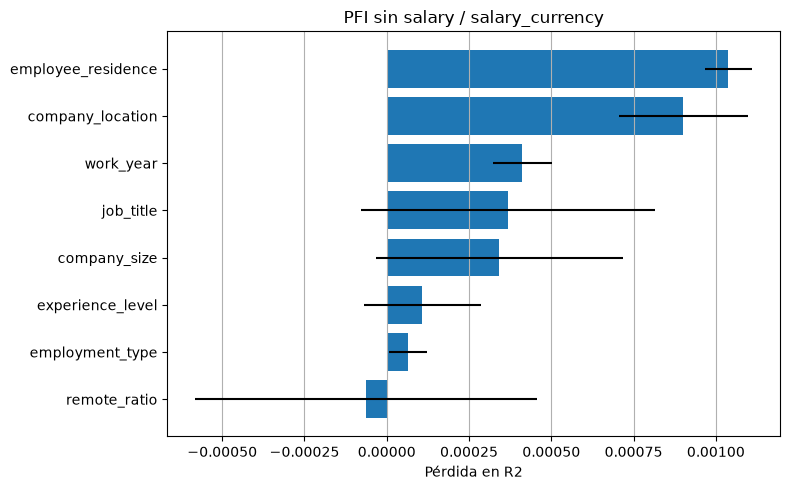

In [ ]:
# se filtran las dos variables que llaman la atencion en el grafico anterior y volvemos 
# a graficar para ver las variables restantes que valores no son tan altos

pfi_sin_leak = pfi[~pfi["feature"].isin(["salary", "salary_currency"])]
plt.figure(figsize=(8, 5))
plt.barh(pfi_sin_leak["feature"], pfi_sin_leak["importance"], xerr=pfi_sin_leak["std"])
plt.xlabel("Pérdida en R2")
plt.title("PFI sin salary / salary_currency")
plt.grid(axis="x")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Resultados preliminares del analisis de resultados Globales.

1. Queda muy envidencia que las variables mas relevantes son **salary** y **salary_currency** y que quitando estas las demas son irrelevantes. 



#### 5. Diagnostico Local (SHAP)

--->> Prediccion BAJA (Valor predicho) <<---
work_year                                      2023
experience_level                                 EN
employment_type                                  FT
job_title             Autonomous Vehicle Technician
salary                                         7000
salary_currency                                 USD
employee_residence                               GH
remote_ratio                                      0
company_location                                 GH
company_size                                      S
Name: 573, dtype: object
--->> Caso 1: Prediccion BAJA (Valor predicho: 7697.22) <<---


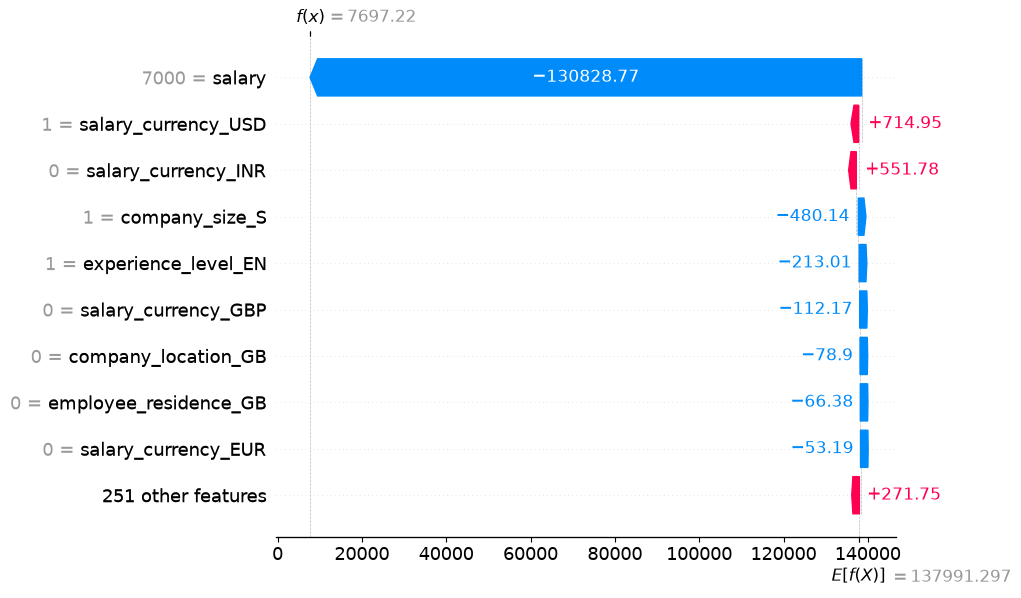

In [ ]:
# importaciones necesarias paradiagnostico Local (SHAP)
import shap

# 1. extraemos el modelo y transformamos los datos con el preprocesador
modelo_rf = rf_pipeline.named_steps['model']
preprocesador = rf_pipeline.named_steps['preprocessor']
X_test_prep = preprocesador.transform(X_test)

# 2. Reconstruimos los nombres de las columnas post transformación
cat_cols = preprocesador.named_transformers_['cat'].get_feature_names_out(categorical_col)
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
feature_names = list(cat_cols) + num_cols

# 2.1 Convertimos a DataFrame para que SHAP lea los nombres automaticamente
if hasattr(X_test_prep, "toarray"):
    X_test_prep = X_test_prep.toarray() 
    # Convertimos matriz sparse a densa si es necesario
X_test_df = pd.DataFrame(X_test_prep, columns=feature_names)

# 3. Seleccionamos dos casos extremos basados en nuestras predicciones
idx_baja = y_pred.argmin()
idx_alta = y_pred.argmax()

# 4. Instanciamos el explainer de SHAP y calculamos los valores
explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer(X_test_df.iloc[[idx_baja, idx_alta]])

# 5. Graficamos el Caso 1 (Prediccion Baja)
print(f"--->> Prediccion BAJA (Valor predicho) <<---")
print(X_test.iloc[idx_baja] )
print(f"--->> Caso 1: Prediccion BAJA (Valor predicho: {y_pred[idx_baja]:.2f}) <<---")
shap.plots.waterfall(shap_values[0])



### Analisis Caso 1
##### ¿Qué variables contribuyeron más? 
Claramente la variable que mas contibuye es **`salary`** que se lleva casi toda la explicacion. Los demas features son rudio con pequenas variaciones positivas y negativas: `salary_currency_USD` (+715),  `company_size_S` (−480), `experience_level_EN` (−213).
##### ¿En qué dirección?
El `salary`bajo **resta** ~131.000 y deja la prediccion en ~7.700. Las variables “de negocio” (experiencia, rol, país) casi no mueven el resultado.
##### ¿La explicación es coherente con el análisis global?
Es coherente porque en ambos analisis hay una dominacion clara, en el ranking global `salary` varia 1.91, muchas otras variaciones bajas `salary_currency` 0.44, experiencia/rol/país ≤ 0.001 y en el analisis local se ve un funcionamiento similar, donde el modelo no “entiende” que es un Junior en GH; convierte 7.000 USD. 

work_year                               2022
experience_level                          SE
employment_type                           FT
job_title             Data Science Tech Lead
salary                                375000
salary_currency                          USD
employee_residence                        US
remote_ratio                              50
company_location                          US
company_size                               L
Name: 2359, dtype: object
--->> Caso 2: Prediccion ALTA (Valor predicho: 379113.61) <<---


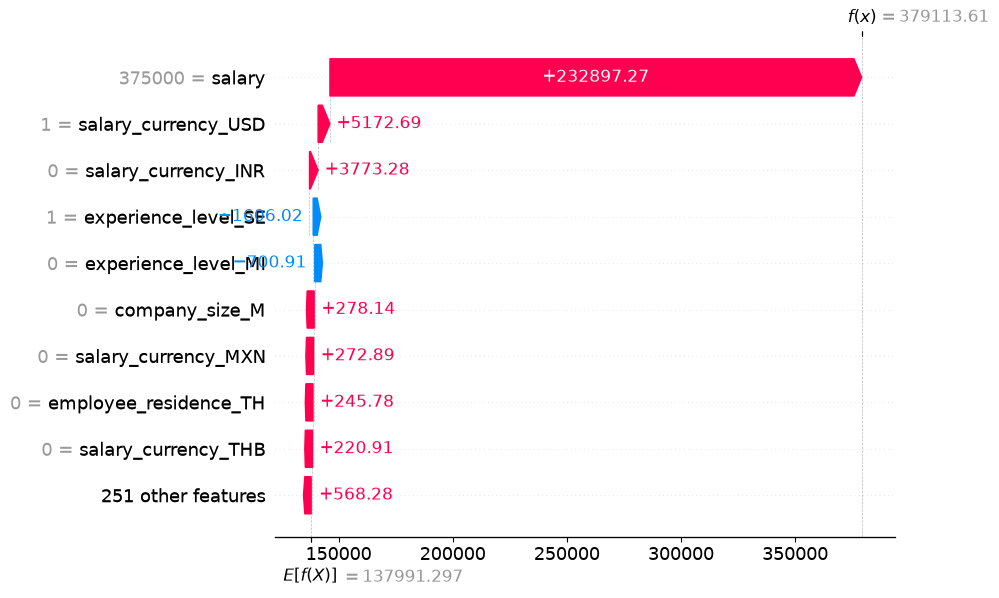

In [ ]:
# 6. Graficamos el Caso 2 (Prediccion Alta)
print(X_test.iloc[idx_alta] )
print(f"--->> Caso 2: Prediccion ALTA (Valor predicho: {y_pred[idx_alta]:.2f}) <<---")
shap.plots.waterfall(shap_values[1])


### Analisis Caso 2
#### ¿Qué variables contribuyeron más? 
De vuelta `salary` tiene un SHAP +232897, y despues aparen otras variables como de moneda (`salary_currency_USD` +5.200, `salary_currency_INR` +3.800 por *no* ser INR). `experience_level_SE` aporta apenas −1.600: un ajuste chico, no el driver.
#### ¿En qué dirección? 
Sobre la misma base de ~138.000, como en el caso anterior, ahora `salary` **suma** ~233.000, llegando a ~379.000, donde un salario alto empuja hacia arriba, similar al caso uno pero inverso.
#### ¿La explicación es coherente con el análisis global?
Se mantiene la coherencia, donde ambos analisis hay una dominacion clara, al igual que en el ranking global, `salary` varia positivamente, pero deja fuera Experiencia por ejemplo que deberia ser a mi entender considerada en una prediccion de salario de mercado.


#### 5. Auditoria

In [ ]:
# Para avanzar con la Auditoria, y en base a los resultados de los analisis previos, se decide eliminar 
# las variables que causan data leakage y volver a entrenar el modelo.


# 1. Eliminamos las variables que causan problemas con la fuga de datos
X_clean = X.drop(columns=['salary', 'salary_currency'])

# 2. Dividimos nuevamente los datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

# 3. Identificamos las nuevas columnas categoricas
cat_cols_clean = X_clean.select_dtypes(include=['object']).columns.tolist()

# 4. Creamos el nuevo preprocesador y pipeline nuevamente.
preprocessor_clean = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_clean),
    ],
    remainder='passthrough'
)

rf_pipeline_clean = Pipeline(steps=[
    ('preprocessor', preprocessor_clean),
    ('model', RandomForestRegressor(random_state=42))
])

# 5. Entrenamos el nuevo modelo
rf_pipeline_clean.fit(X_train_c, y_train_c)

# 6. Evaluamos el desempeño realista
y_pred_c = rf_pipeline_clean.predict(X_test_c)

print("--->> Comparación de Modelos <<---")
print("Modelo Original (CON Leakage) -> R2: 0.9832 | RMSE: 8148.56")
print(f"Modelo Corregido (SIN Leakage) -> R2: {r2_score(y_test_c, y_pred_c):.4f} | RMSE: {root_mean_squared_error(y_test_c, y_pred_c):.2f}")

/var/folders/d9/jdkvkdkj05vcnpwfbz5dxz7m0000gn/T/ipykernel_10490/2758115563.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_clean = X_clean.select_dtypes(include=['object']).columns.tolist()


--->> Comparación de Modelos <<---
Modelo Original (CON Leakage) -> R2: 0.9832 | RMSE: 8148.56
Modelo Corregido (SIN Leakage) -> R2: 0.3997 | RMSE: 48682.42


### Auditoría

#### Hallazgo 1

#### **¿Qué evidencia proporcionan las técnicas de interpretabilidad?**
La evidencia muestra que el Diagnostico Global PFI del modelo original asigna 1.91 a `salary` y 0.44 a `salary_currency`; el resto queda en ≤ 0.001. En SHAP, la predicción baja (~7.7k) es empujada **hacia abajo** por un `salary` chico, y la alta (~379k) es empujada **hacia arriba** por un `salary` grande, desde un valor base cercano a la media del modelo. En las dos tecnicas se puede ver que el modelo casi no usa experiencia, rol ni ubicación.

#### **¿El comportamiento es razonable para el problema?**
No. Si el objetivo es predecir `salary_in_usd`, en producción no vamos a tener el salario en otra moneda. Un R2 de 0.98 y un MAE de ~1.2k son demasiado buenos para este problema: el modelo pareceria no estimar, sino convertir.

#### **¿Qué posible causa podría explicar ese comportamiento?**
Pareceria ser un caso de Data Leakage o Fuga de Información. **salary** y **salary_in_usd** representan exactamente la misma información, que es el sueldo, solo que en diferentes monedas.

#### **¿Qué acción tomarían para investigarlo o corregirlo?**
Eliminar las columnas **salary** y **salary_currency** del dataset de entrenamiento (X), reentrenar el modelo y verificar que las nuevas metricas (como el R2) bajen a un nivel realista, intentando obligar al modelo a buscar patrones reales en la experiencia, ubicacion y tipo de trabajo.


#### Hallazgo 2
| | Con leakage | Sin leakage |
|---|---|---|
| R2 | 0.983 | 0.400 |
| RMSE | 8.149 | 48.682 |
| Variables que importan | `salary`, `salary_currency` | `employee_residence` (0.36), `experience_level` (0.18), `job_title` (0.16) |

La caída de performance no es un fracaso: es el modelo dejando de copiarse la respuesta. El nuevo ranking es coherente con salarios de data science (mercado del empleado, seniority, rol).

**Redundancia.** `employee_residence` y `company_location` se parecen (muchos US/US). En el PFI limpio gana residence (0.36 vs 0.02): el mercado donde vive la persona pesa más que el de la empresa. No hace falta borrarlas para este TP; sí conviene no leerlas como dos señales independientes.

**¿Es razonable ahora?** Sí, dentro de lo que se puede pedir a un RF por defecto. Un R2 de 0.40 es creíble; un 0.98 no lo era.


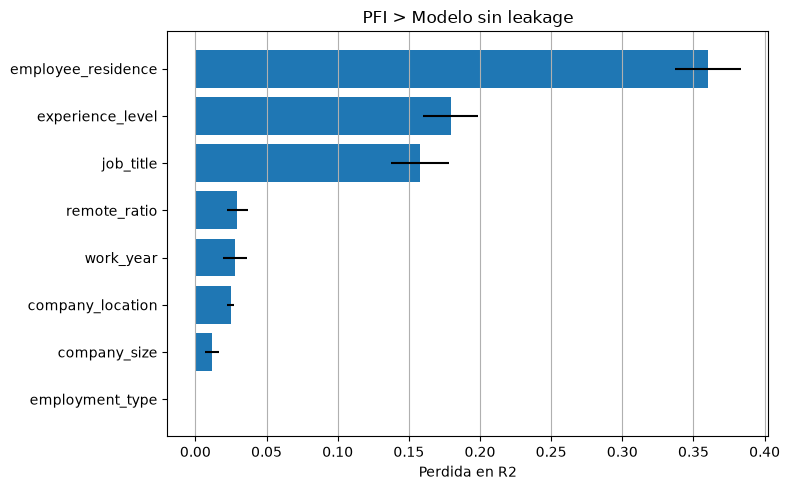

Importancia media de las variables en el modelo corregido:
employee_residence: 0.3601
experience_level: 0.1793
job_title: 0.1578
remote_ratio: 0.0294
work_year: 0.0276
company_location: 0.0247
company_size: 0.0118
employment_type: -0.0002


In [ ]:
# CONSIGNA: Si detectan leakage, eliminar la variable problemática, reentrenar el modelo y comparar
# brevemente con el modelo original: performance, importancia de las variables y
# razonabilidad del comportamiento. No es necesario repetir todo el análisis detallado de
# interpretabilidad.


# PFI del modelo ya reentrenado, sin salary / salary_currency
pfi_result_clean = permutation_importance(
    rf_pipeline_clean, X_test_c, y_test_c, n_repeats=10, random_state=42, n_jobs=-1
)

pfi_clean = pd.DataFrame({
    "feature": X_test_c.columns,
    "importance": pfi_result_clean.importances_mean,
    "std": pfi_result_clean.importances_std
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(pfi_clean["feature"], pfi_clean["importance"], xerr=pfi_clean["std"])
plt.xlabel("Perdida en R2")
plt.title("PFI > Modelo sin leakage")
plt.grid(axis="x")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Importancia media de las variables en el modelo corregido:")
for _, row in pfi_clean.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")